# Lab 03: CSI 300 Regression And Visualization

This notebook completes:

1. data loading and preprocessing
2. feature selection
3. train/test split
4. linear regression training
5. prediction and evaluation

The generated figures are also saved under the `result` directory for report writing.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["axes.unicode_minus"] = False


def configure_chinese_font():
    font_candidates = [
        Path(r"C:/Windows/Fonts/msyh.ttc"),
        Path(r"C:/Windows/Fonts/simhei.ttf"),
        Path(r"C:/Windows/Fonts/simsun.ttc"),
    ]
    for font_path in font_candidates:
        if not font_path.exists():
            continue
        try:
            fm.fontManager.addfont(str(font_path))
        except Exception:
            pass
        font_name = fm.FontProperties(fname=str(font_path)).get_name()
        plt.rcParams["font.family"] = font_name
        plt.rcParams["font.sans-serif"] = [font_name]
        matplotlib.rcParams["font.family"] = font_name
        matplotlib.rcParams["font.sans-serif"] = [font_name]
        return fm.FontProperties(fname=str(font_path))
    return None


cn_font = configure_chinese_font()
sns.set_theme(
    style="whitegrid",
    rc={
        "font.family": plt.rcParams["font.family"],
        "font.sans-serif": plt.rcParams["font.sans-serif"],
        "axes.unicode_minus": False,
    },
)


def find_csv_path():
    search_dirs = [Path.cwd(), Path.cwd() / "code", Path(".."), Path("../code")]
    for folder in search_dirs:
        if folder.exists():
            candidates = sorted(folder.glob("*.csv"))
            if candidates:
                return candidates[0].resolve()
    raise FileNotFoundError("CSV data file was not found.")


def find_result_dir():
    search_dirs = [Path.cwd() / "result", Path.cwd().parent / "result", Path("result"), Path("../result")]
    for folder in search_dirs:
        if folder.exists():
            return folder.resolve()
    folder = (Path.cwd().parent / "result").resolve()
    folder.mkdir(parents=True, exist_ok=True)
    return folder


def save_current_figure(filename):
    plt.savefig(result_dir / filename, dpi=300, bbox_inches="tight")


def apply_font(ax):
    if cn_font is None:
        return
    text_items = [ax.title, ax.xaxis.label, ax.yaxis.label]
    text_items.extend(ax.get_xticklabels())
    text_items.extend(ax.get_yticklabels())
    for item in text_items:
        item.set_fontproperties(cn_font)
    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontproperties(cn_font)
        legend.get_title().set_fontproperties(cn_font)


## 1. Data Loading And Preprocessing


In [3]:
data_path = find_csv_path()
result_dir = find_result_dir()
raw_df = pd.read_csv(data_path, encoding="utf-8-sig")

date_col, target_col, open_col, high_col, low_col, volume_col, pct_col = raw_df.columns.tolist()

print(f"data_path = {data_path}")
print(f"result_dir = {result_dir}")
print(f"raw_shape = {raw_df.shape}")
display(raw_df.head())


data_path = C:\Users\32610\数据挖掘与机器学习\实验三\code\沪深300_最近三年.csv
result_dir = C:\Users\32610\数据挖掘与机器学习\实验三\result
raw_shape = (725, 7)


,日期,收盘,开盘,高,低,交易量,涨跌幅
0,2026-03-18,"4,619.6200","4,648.7500","4,651.4300","4,604.5200",169361.41K,-0.38%
1,2026-03-17,"4,637.4400","4,685.5700","4,720.8600","4,637.3700",263021.91K,-0.73%
2,2026-03-16,"4,671.5600","4,669.2200","4,673.6900","4,621.8100",296215.07K,0.05%
3,2026-03-13,"4,669.1400","4,669.0600","4,707.4200","4,659.5000",310772.01K,-0.39%
4,2026-03-12,"4,687.5600","4,700.7200","4,704.3800","4,654.3100",302986.82K,-0.36%


In [4]:
df = raw_df.copy()
df[date_col] = pd.to_datetime(df[date_col])
df[volume_col] = df[volume_col].astype(str).str.replace("K", "", regex=False).astype(float) * 1000
df[pct_col] = pd.to_numeric(df[pct_col].astype(str).str.replace("%", "", regex=False), errors="coerce")
df = df.sort_values(date_col).reset_index(drop=True)

missing_before = df.isna().sum()
duplicate_count = df.duplicated().sum()
rows_before = len(df)

df[pct_col] = df[pct_col].fillna(df[pct_col].median())
df = df.drop_duplicates().reset_index(drop=True)

df["year"] = df[date_col].dt.year
df["month"] = df[date_col].dt.month
df["day"] = df[date_col].dt.day
df["weekday"] = df[date_col].dt.weekday + 1

numeric_cols = [target_col, open_col, high_col, low_col, volume_col, pct_col]
q1 = df[numeric_cols].quantile(0.25)
q3 = df[numeric_cols].quantile(0.75)
iqr = q3 - q1
lower_bounds = q1 - 1.5 * iqr
upper_bounds = q3 + 1.5 * iqr
outlier_counts = ((df[numeric_cols] < lower_bounds) | (df[numeric_cols] > upper_bounds)).sum()
df[numeric_cols] = df[numeric_cols].clip(lower=lower_bounds, upper=upper_bounds, axis=1)

summary_df = pd.DataFrame(
    {
        "item": ["rows_before", "rows_after", "duplicates_removed", "missing_before", "missing_after"],
        "value": [rows_before, len(df), duplicate_count, int(missing_before.sum()), int(df.isna().sum().sum())],
    }
)

display(summary_df)
display(outlier_counts.rename("outlier_count").to_frame())


,item,value
0,rows_before,725
1,rows_after,725
2,duplicates_removed,0
3,missing_before,1
4,missing_after,0


,outlier_count
收盘,6
开盘,3
高,1
低,2
交易量,24
涨跌幅,34


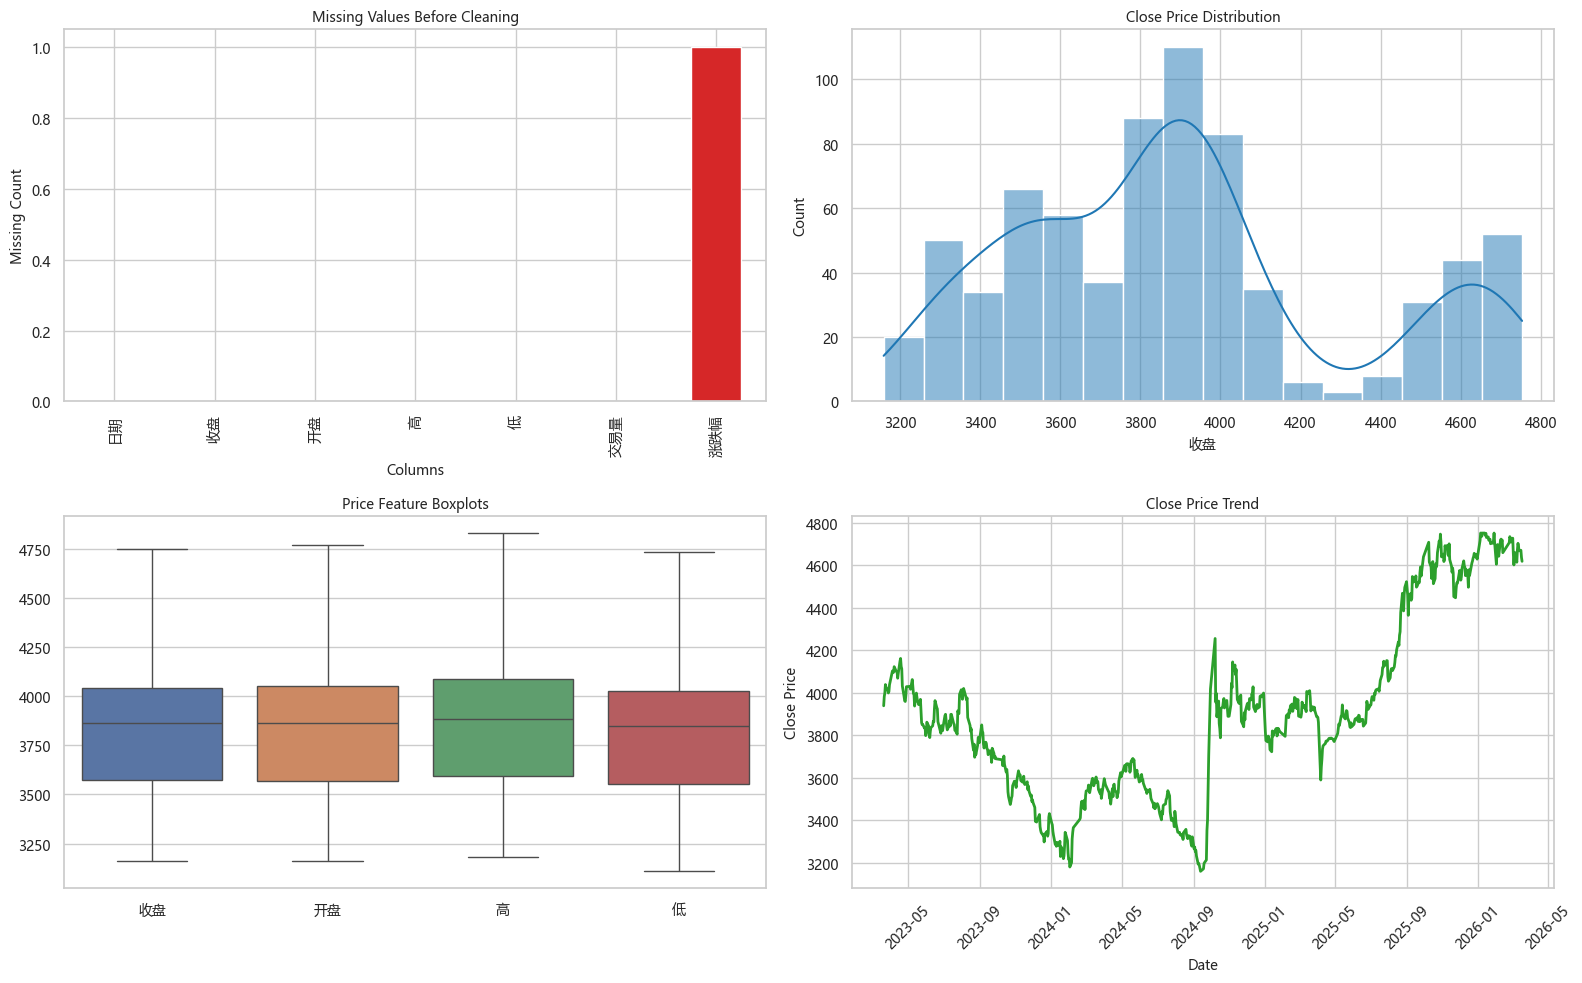

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

missing_before.plot(kind="bar", ax=axes[0, 0], color="#d62728")
axes[0, 0].set_title("Missing Values Before Cleaning")
axes[0, 0].set_xlabel("Columns")
axes[0, 0].set_ylabel("Missing Count")

sns.histplot(df[target_col], kde=True, ax=axes[0, 1], color="#1f77b4")
axes[0, 1].set_title("Close Price Distribution")

sns.boxplot(data=df[[target_col, open_col, high_col, low_col]], ax=axes[1, 0])
axes[1, 0].set_title("Price Feature Boxplots")

axes[1, 1].plot(df[date_col], df[target_col], color="#2ca02c", linewidth=2)
axes[1, 1].set_title("Close Price Trend")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Close Price")
axes[1, 1].tick_params(axis="x", rotation=45)

for ax in axes.flat:
    apply_font(ax)
plt.tight_layout()
save_current_figure("fig1_preprocess_overview.png")
plt.show()


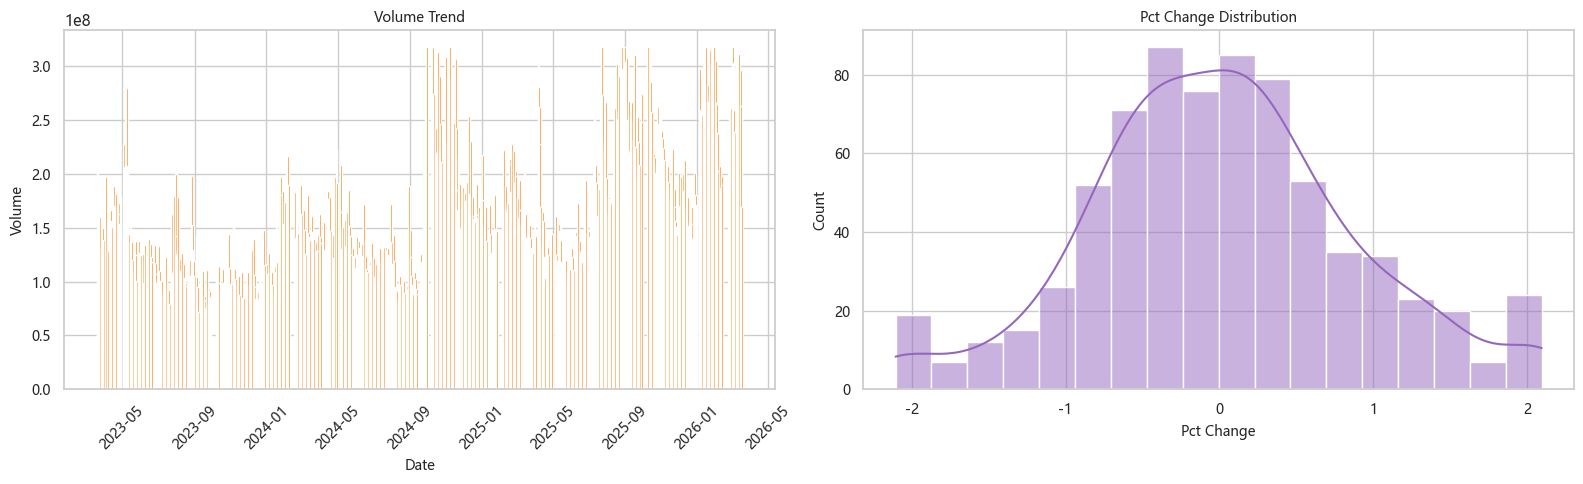

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(df[date_col], df[volume_col], color="#ff7f0e", width=3)
axes[0].set_title("Volume Trend")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Volume")
axes[0].tick_params(axis="x", rotation=45)

sns.histplot(df[pct_col], kde=True, ax=axes[1], color="#9467bd")
axes[1].set_title("Pct Change Distribution")
axes[1].set_xlabel("Pct Change")

for ax in axes.flat:
    apply_font(ax)
plt.tight_layout()
save_current_figure("fig2_volume_pct.png")
plt.show()


## 2. Feature Selection


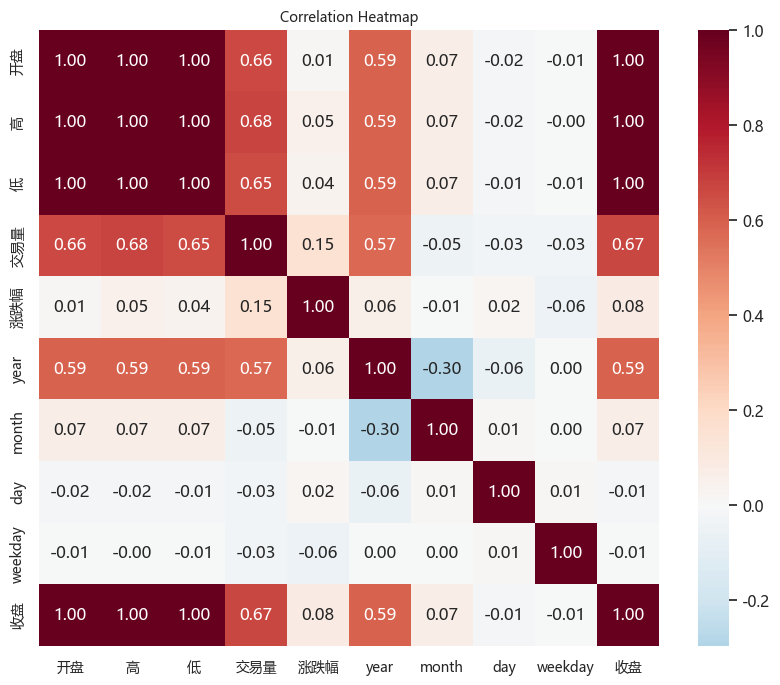

,abs_corr_with_target
高,0.9983
低,0.9981
开盘,0.9961
交易量,0.6663
year,0.5903
涨跌幅,0.0825
month,0.0690
day,0.0147
weekday,0.0069


In [8]:
candidate_features = [open_col, high_col, low_col, volume_col, pct_col, "year", "month", "day", "weekday"]
corr_df = df[candidate_features + [target_col]].corr()
corr_with_target = corr_df[target_col].drop(target_col).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
apply_font(plt.gca())
save_current_figure("fig3_correlation_heatmap.png")
plt.show()

display(corr_with_target.to_frame(name="abs_corr_with_target"))


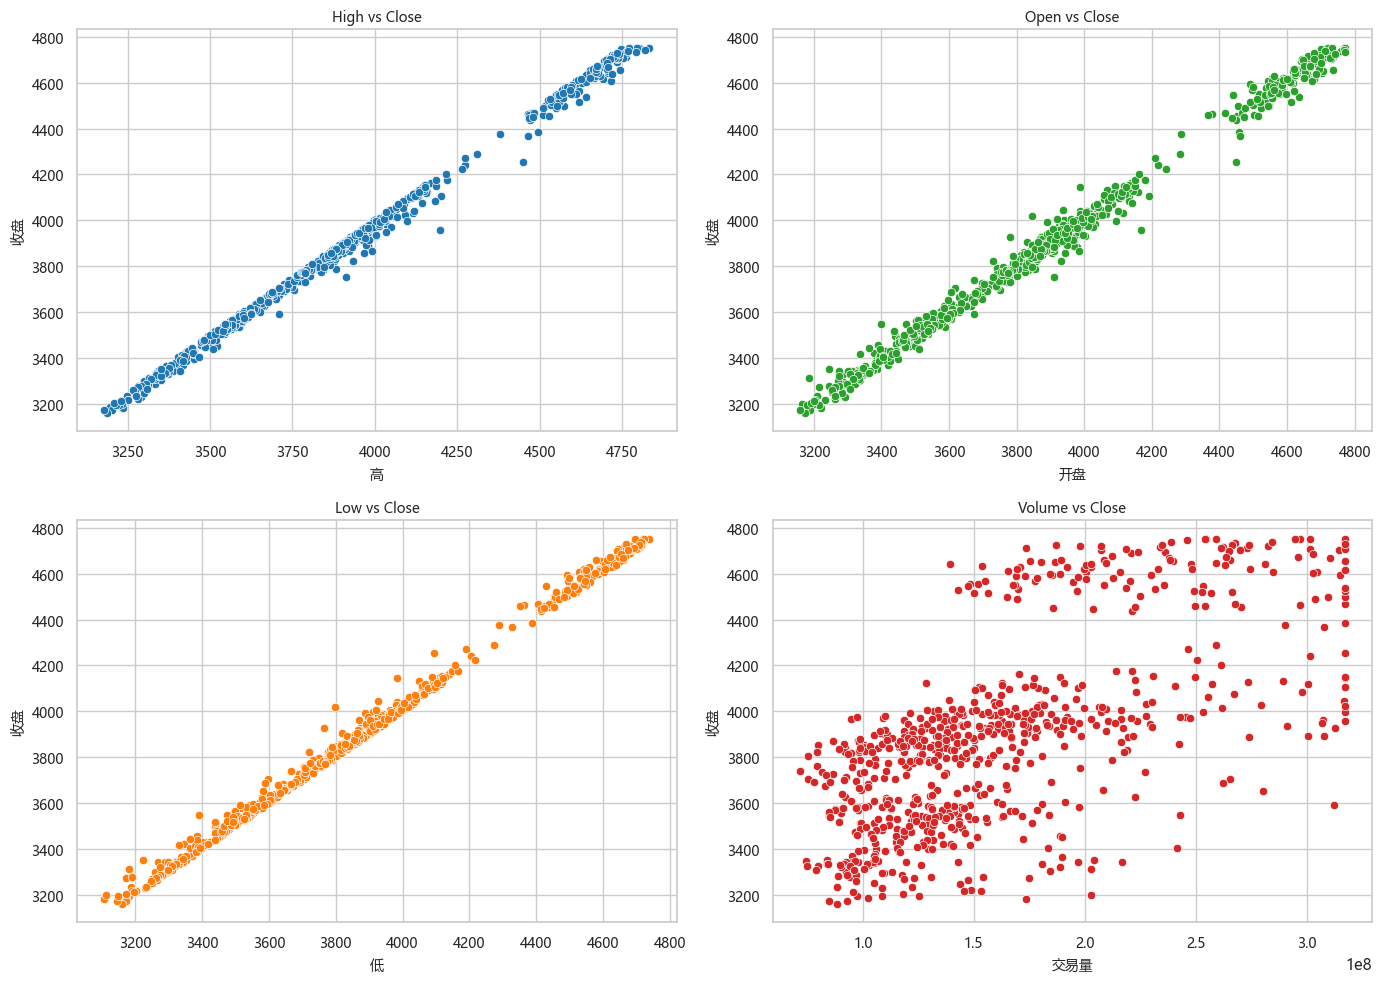

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(x=df[high_col], y=df[target_col], ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("High vs Close")

sns.scatterplot(x=df[open_col], y=df[target_col], ax=axes[0, 1], color="#2ca02c")
axes[0, 1].set_title("Open vs Close")

sns.scatterplot(x=df[low_col], y=df[target_col], ax=axes[1, 0], color="#ff7f0e")
axes[1, 0].set_title("Low vs Close")

sns.scatterplot(x=df[volume_col], y=df[target_col], ax=axes[1, 1], color="#d62728")
axes[1, 1].set_title("Volume vs Close")

for ax in axes.flat:
    apply_font(ax)
plt.tight_layout()
save_current_figure("fig4_feature_scatter.png")
plt.show()


In [10]:
high_corr_threshold = 0.95
dominant_ratio_threshold = 0.95
target_corr_threshold = 0.10

feature_corr = df[candidate_features].corr().abs()
upper = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))

high_corr_records = []
drop_high_corr = set()
for col in upper.columns:
    related_rows = upper.index[upper[col] > high_corr_threshold].tolist()
    for row in related_rows:
        keep_feature = row if corr_with_target[row] >= corr_with_target[col] else col
        drop_feature = col if keep_feature == row else row
        high_corr_records.append(
            {
                "feature_1": row,
                "feature_2": col,
                "correlation": upper.loc[row, col],
                "keep": keep_feature,
                "drop": drop_feature,
            }
        )
        drop_high_corr.add(drop_feature)

dominant_ratio = df[candidate_features].apply(lambda s: s.value_counts(normalize=True, dropna=False).iloc[0])
drop_dominant = dominant_ratio[dominant_ratio > dominant_ratio_threshold].index.tolist()
leakage_features = [pct_col]

feature_decisions = []
selected_features = []
for feature in candidate_features:
    if feature in drop_high_corr:
        decision = "drop_high_correlation"
    elif feature in drop_dominant:
        decision = "drop_dominant_single_value"
    elif feature in leakage_features:
        decision = "drop_target_leakage"
    elif corr_with_target[feature] < target_corr_threshold:
        decision = "drop_low_target_correlation"
    else:
        decision = "keep"
        selected_features.append(feature)

    feature_decisions.append(
        {
            "feature": feature,
            "abs_corr_with_target": corr_with_target[feature],
            "dominant_ratio": dominant_ratio[feature],
            "decision": decision,
        }
    )

high_corr_result = pd.DataFrame(high_corr_records)
feature_selection_df = pd.DataFrame(feature_decisions).sort_values("abs_corr_with_target", ascending=False)

display(high_corr_result)
display(feature_selection_df)
print("selected_features =", selected_features)


,feature_1,feature_2,correlation,keep,drop
0,开盘,高,0.9983,高,开盘
1,开盘,低,0.9980,低,开盘
2,高,低,0.9974,高,低


,feature,abs_corr_with_target,dominant_ratio,decision
1,高,0.9983,0.0028,keep
2,低,0.9981,0.0028,drop_high_correlation
0,开盘,0.9961,0.0041,drop_high_correlation
3,交易量,0.6663,0.0331,keep
5,year,0.5903,0.3352,keep
4,涨跌幅,0.0825,0.0262,drop_target_leakage
6,month,0.0690,0.0924,drop_low_target_correlation
7,day,0.0147,0.0372,drop_low_target_correlation
8,weekday,0.0069,0.2041,drop_low_target_correlation


selected_features = ['高', '交易量', 'year']


## 3. Train Test Split


In [12]:
X = df[selected_features].copy()
y = df[target_col].copy()

split_index = int(len(df) * 0.8)
X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

split_summary = pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "samples": [len(X_train), len(X_test)],
        "ratio": [f"{len(X_train) / len(df):.1%}", f"{len(X_test) / len(df):.1%}"],
        "date_range": [
            f"{df.loc[0, date_col].date()} to {df.loc[split_index - 1, date_col].date()}",
            f"{df.loc[split_index, date_col].date()} to {df.loc[len(df) - 1, date_col].date()}",
        ],
    }
)
display(split_summary)


,dataset,samples,ratio,date_range
0,train,580,80.0%,2023-03-20 to 2025-08-07
1,test,145,20.0%,2025-08-08 to 2026-03-18


## 4. Linear Regression Training


In [14]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

train_pred = linear_model.predict(X_train)
test_pred = linear_model.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
mae_value = mean_absolute_error(y_test, test_pred)
rmse_value = np.sqrt(mean_squared_error(y_test, test_pred))

coef_df = pd.DataFrame(
    {
        "feature": selected_features,
        "coefficient": linear_model.coef_,
    }
).sort_values("coefficient", key=np.abs, ascending=False)

metric_df = pd.DataFrame(
    {
        "metric": ["train_R2", "test_R2", "MAE", "RMSE"],
        "value": [train_r2, test_r2, mae_value, rmse_value],
    }
)

print(f"intercept = {linear_model.intercept_:.4f}")
display(coef_df)
display(metric_df)


intercept = -8848.0062


,feature,coefficient
2,year,4.3716
0,高,1.0007
1,交易量,-0.0000


,metric,value
0,train_R2,0.9919
1,test_R2,0.9700
2,MAE,19.4588
3,RMSE,24.3403


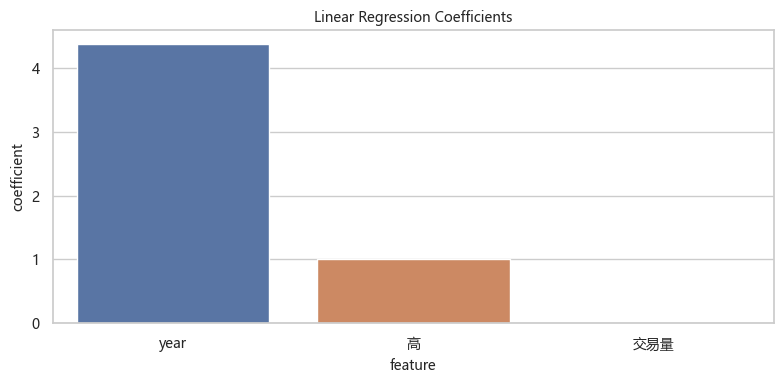

In [15]:
plt.figure(figsize=(8, 4))
sns.barplot(data=coef_df, x="feature", y="coefficient", palette="deep")
plt.title("Linear Regression Coefficients")
apply_font(plt.gca())
plt.tight_layout()
save_current_figure("fig5_model_coefficients.png")
plt.show()


## 5. Prediction And Evaluation


In [17]:
result_df = pd.DataFrame(
    {
        "date": df.loc[y_test.index, date_col].values,
        "actual_close": y_test.values,
        "predicted_close": test_pred,
    }
)
result_df["absolute_error"] = (result_df["actual_close"] - result_df["predicted_close"]).abs()
result_df["residual"] = result_df["actual_close"] - result_df["predicted_close"]

display(result_df.head(10))


,date,actual_close,predicted_close,absolute_error,residual
0,2025-08-08,"4,104.9700","4,099.9362",5.0338,5.0338
1,2025-08-11,"4,122.5100","4,109.0194",13.4906,13.4906
2,2025-08-12,"4,143.8300","4,130.3319",13.4981,13.4981
3,2025-08-13,"4,176.5800","4,157.5241",19.0559,19.0559
4,2025-08-14,"4,173.3100","4,189.8775",16.5675,-16.5675
5,2025-08-15,"4,202.3500","4,177.3875",24.9625,24.9625
6,2025-08-18,"4,239.4100","4,228.7660",10.6440,10.6440
7,2025-08-19,"4,223.3700","4,228.7275",5.3575,-5.3575
8,2025-08-20,"4,271.4000","4,237.3978",34.0022,34.0022
9,2025-08-21,"4,288.0700","4,271.5696",16.5004,16.5004


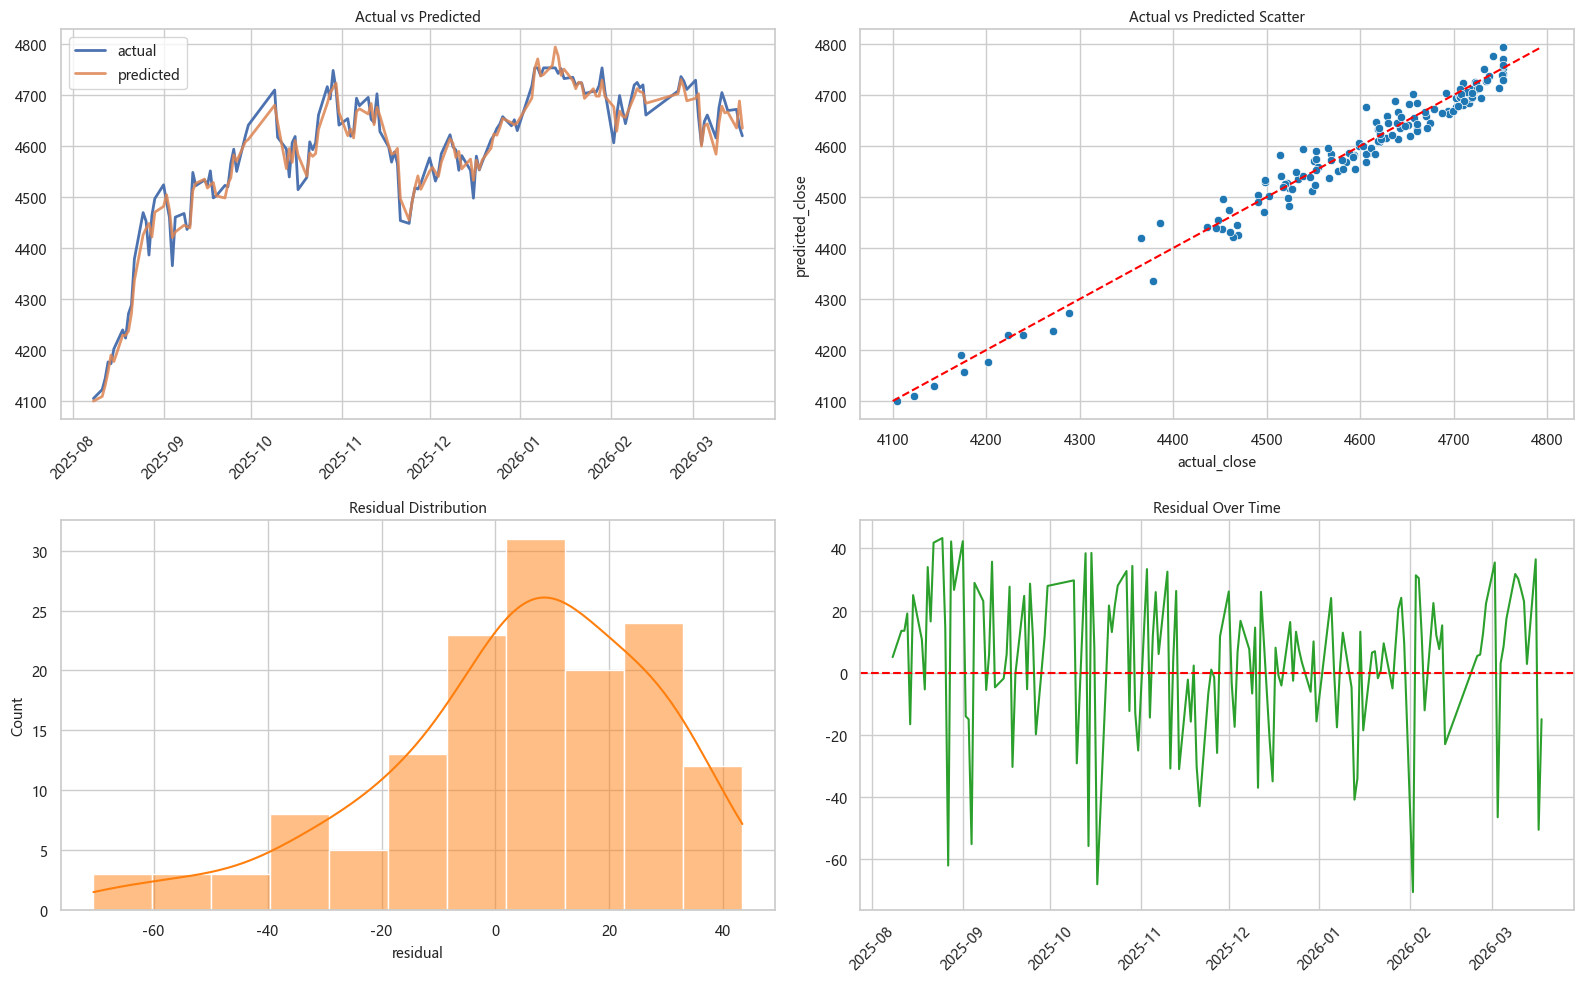

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(result_df["date"], result_df["actual_close"], label="actual", linewidth=2)
axes[0, 0].plot(result_df["date"], result_df["predicted_close"], label="predicted", linewidth=2, alpha=0.85)
axes[0, 0].set_title("Actual vs Predicted")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].legend()

sns.scatterplot(x=result_df["actual_close"], y=result_df["predicted_close"], ax=axes[0, 1], color="#1f77b4")
min_val = min(result_df["actual_close"].min(), result_df["predicted_close"].min())
max_val = max(result_df["actual_close"].max(), result_df["predicted_close"].max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red")
axes[0, 1].set_title("Actual vs Predicted Scatter")

sns.histplot(result_df["residual"], kde=True, ax=axes[1, 0], color="#ff7f0e")
axes[1, 0].set_title("Residual Distribution")

axes[1, 1].plot(result_df["date"], result_df["residual"], color="#2ca02c")
axes[1, 1].axhline(0, linestyle="--", color="red")
axes[1, 1].set_title("Residual Over Time")
axes[1, 1].tick_params(axis="x", rotation=45)

for ax in axes.flat:
    apply_font(ax)
plt.tight_layout()
save_current_figure("fig6_prediction_residuals.png")
plt.show()


## Conclusion

- The selected features are expected to be the daily high price, trading volume, and year.
- The test R2 is close to 1, which indicates a good fit for this assignment dataset.
- All report figures are saved under the result directory.
